### Wine Consumption Exploratory Analysis

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

**Load the dataset**

In [ ]:
wine_df = pd.read_csv('data/wine-consumption-per-capita.csv')
print("The Wine Consumption dataset contains", wine_df.shape[0], "rows and", wine_df.shape[1], "columns.")

wine_df.rename(columns={'Alcohol, recorded per capita (15+) consumption (in litres of pure alcohol) - Beverage types: Wine': 'Wine Consumption'}, inplace=True)
wine_df.head()

The Wine Consumption dataset contains 10303 rows and 4 columns.


,Entity,Code,Year,Wine Consumption
0,Afghanistan,AFG,1961,0.0
1,Afghanistan,AFG,1962,0.0
2,Afghanistan,AFG,1963,0.0
3,Afghanistan,AFG,1964,0.0
4,Afghanistan,AFG,1965,0.0


In [63]:
wine_df = wine_df.dropna(subset=['Entity', 'Year', 'Wine Consumption'])

print("After removing rows with missing values, the dataset contains", wine_df.shape[0], "rows and", wine_df.shape[1], "columns.")

After removing rows with missing values, the dataset contains 10303 rows and 4 columns.


The dataset does not contain any missing values in the `Entity`, `Year`, and `Wine Consumption` columns, which are the ones that are necessary for our analysis. 

In [64]:
# Blue Zone Countries
blue_zone_countries = ['Italy', 'Greece', 'Japan', 'Costa Rica', 'United States']

blue_zone_df = wine_df[wine_df['Entity'].isin(blue_zone_countries)]

rest_countries_df = wine_df[~wine_df['Entity'].isin(blue_zone_countries)]

**LineChart of Wine Consumption:** It contains a line plot showing the wine consumption of the countries that contain Blue Zone regions and the average wine consumption of the remaining countries over time. 

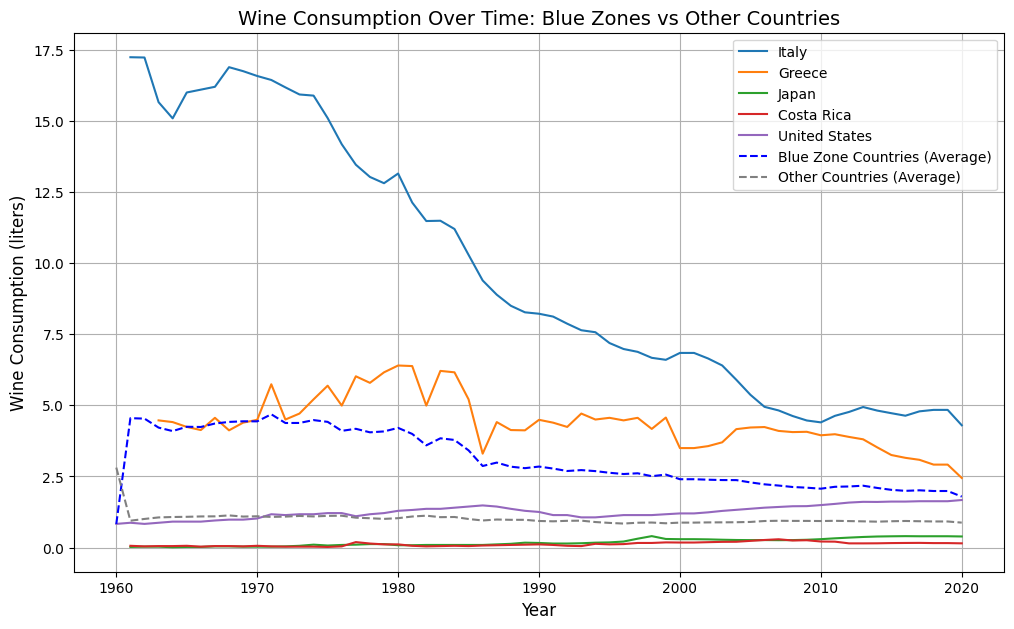

In [65]:
other_countries_avg_by_year = rest_countries_df.groupby('Year')['Wine Consumption'].mean()
blue_zone_countries_avg_by_year = blue_zone_df.groupby('Year')['Wine Consumption'].mean()

plt.figure(figsize=(12, 7))

for country in blue_zone_countries:
    country_data = blue_zone_df[blue_zone_df['Entity'] == country].sort_values('Year')
    plt.plot(country_data['Year'], country_data['Wine Consumption'], label=country)

plt.plot(blue_zone_countries_avg_by_year.index, blue_zone_countries_avg_by_year.values, label='Blue Zone Countries (Average)', linestyle='--', color='blue')

plt.plot(other_countries_avg_by_year.index, other_countries_avg_by_year.values, label='Other Countries (Average)', linestyle='--', color='gray')

plt.xlabel('Year', fontsize=12)
plt.ylabel('Wine Consumption (liters)', fontsize=12)
plt.title('Wine Consumption Over Time: Blue Zones vs Other Countries', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True)
plt.show()

In [66]:
# for 2020 we do not have data for Serbia and Montenegro
print("The average wine consumption in Blue Zone countries in 2020 is:", blue_zone_df[blue_zone_df['Year'] == 2020]['Wine Consumption'].mean())
print("The average wine consumption in other countries in 2020 is:", rest_countries_df[rest_countries_df['Year'] == 2020]['Wine Consumption'].mean())

The average wine consumption in Blue Zone countries in 2020 is: 1.789668
The average wine consumption in other countries in 2020 is: 0.8751108241758242


As observed in the data, Italy and Greece have higher wine consumption percentages compared to the rest of the world, while Japan and Costa Rica are at lower levels. In 2020, the average wine consumption per capita in Blue Zone countries was 1.78 litres, compared to 0.87 litres in countries without Blue Zones. However, it is important to note that the starting year for which we have data is not the same for all countries. This uneven coverage may affect the per-year averages, as the number of countries included tends to increase over time.

In [67]:
wine_plot_df = wine_df.copy()
wine_plot_df["Group"] = np.where(wine_plot_df["Entity"].isin(blue_zone_countries),"Blue Zone countries","Other countries")

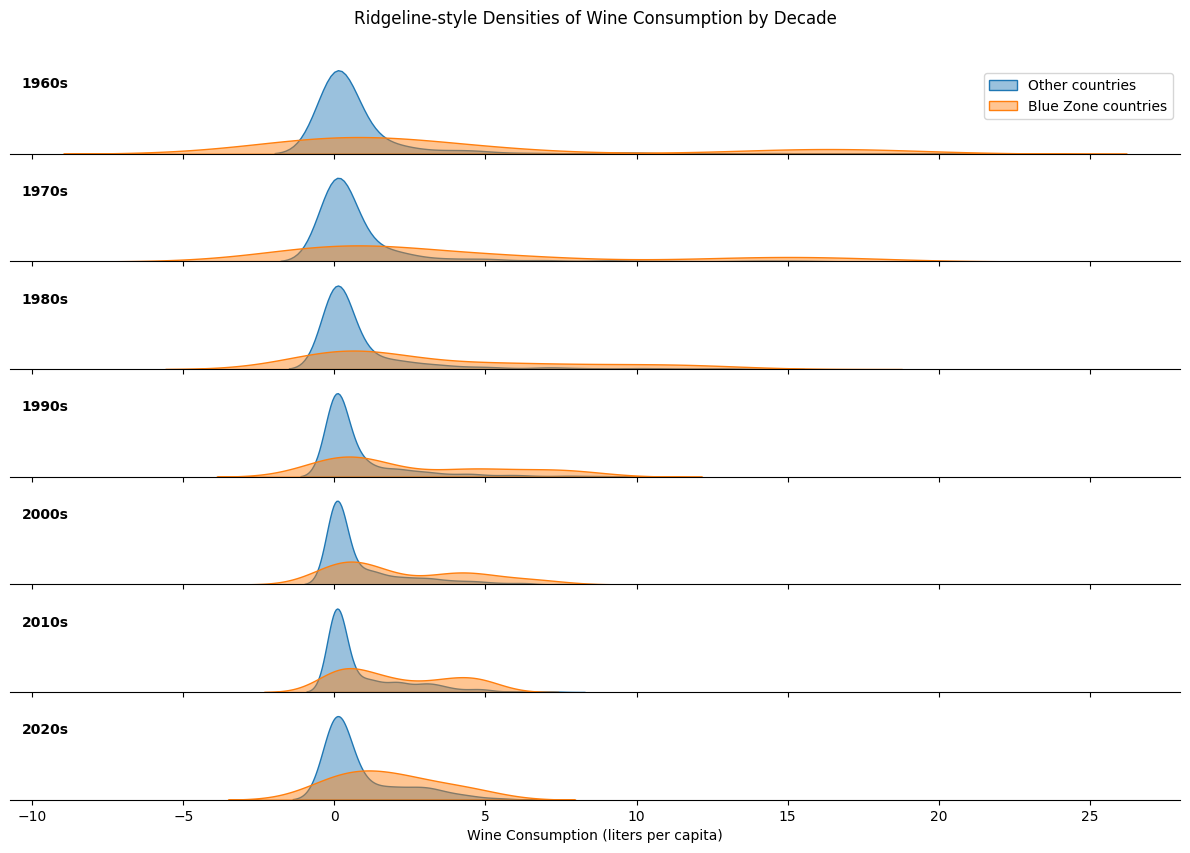

In [68]:
plot_df = wine_plot_df.copy()
plot_df["Decade"] = (plot_df["Year"] // 10) * 10
plot_df = plot_df[plot_df["Decade"] >= 1960]

decades = sorted(plot_df["Decade"].unique())
fig, axes = plt.subplots(len(decades), 1, figsize=(12, 1.2 * len(decades)), sharex=True)

if len(decades) == 1:
    axes = [axes]

for i, dec in enumerate(decades):
    ax = axes[i]
    tmp = plot_df[plot_df["Decade"] == dec]
    sns.kdeplot(
        data=tmp[tmp["Group"] == "Other countries"],
        x="Wine Consumption",
        fill=True,
        alpha=0.45,
        linewidth=1,
        label="Other countries" if i == 0 else None,
        ax=ax
    )
    sns.kdeplot(
        data=tmp[tmp["Group"] == "Blue Zone countries"],
        x="Wine Consumption",
        fill=True,
        alpha=0.45,
        linewidth=1,
        label="Blue Zone countries" if i == 0 else None,
        ax=ax
    )
    ax.text(0.01, 0.75, f"{dec}s", transform=ax.transAxes, fontsize=10, weight="bold")
    ax.set_ylabel("")
    ax.set_yticks([])
    sns.despine(ax=ax, left=True)

axes[0].legend(loc="upper right")
axes[-1].set_xlabel("Wine Consumption (liters per capita)")
fig.suptitle("Ridgeline-style Densities of Wine Consumption by Decade", y=1.01)
plt.tight_layout()
plt.show()

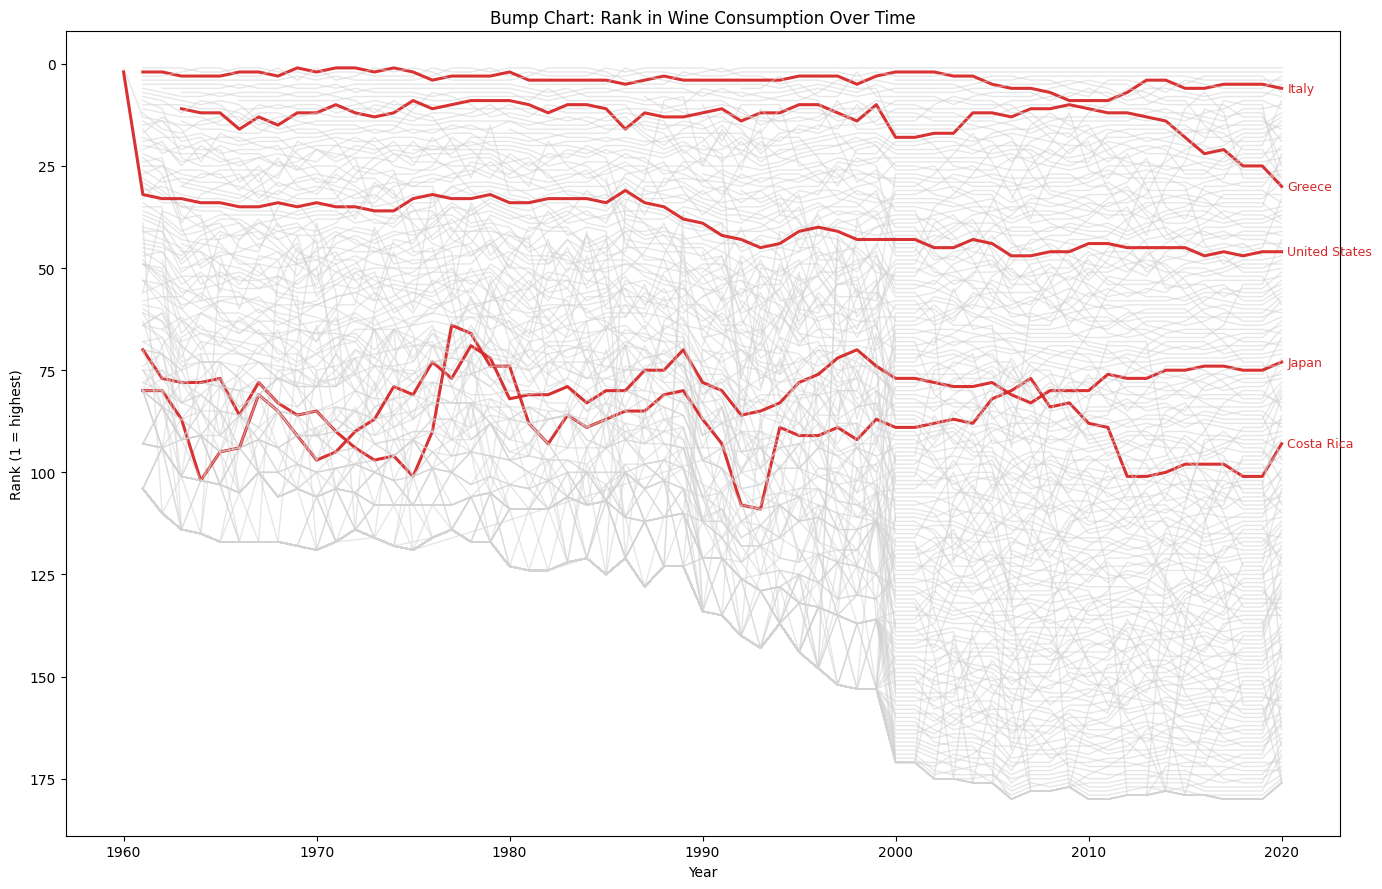

In [69]:
rank_df = wine_df.copy()
rank_df = rank_df[rank_df["Year"] >= 1960]

# Rank each year (1 = highest consumption)
rank_df["Rank"] = rank_df.groupby("Year")["Wine Consumption"].rank(ascending=False, method="min")

eligible = rank_df["Entity"].value_counts()
eligible = eligible.index
rank_df = rank_df[rank_df["Entity"].isin(eligible)]

plt.figure(figsize=(14, 9))
for country, cdf in rank_df.groupby("Entity"):
    cdf = cdf.sort_values("Year")
    is_bz = country in blue_zone_countries
    plt.plot(
        cdf["Year"],
        cdf["Rank"],
        color=("tab:red" if is_bz else "lightgray"),
        linewidth=(2.2 if is_bz else 1),
        alpha=(0.95 if is_bz else 0.55)
    )

# Label Blue Zone lines at last year
for country in blue_zone_countries:
    cdf = rank_df[rank_df["Entity"] == country].sort_values("Year")
    if not cdf.empty:
        x_last = cdf["Year"].iloc[-1]
        y_last = cdf["Rank"].iloc[-1]
        plt.text(x_last + 0.3, y_last, country, fontsize=9, color="tab:red", va="center")

plt.gca().invert_yaxis()
plt.title("Bump Chart: Rank in Wine Consumption Over Time")
plt.xlabel("Year")
plt.ylabel("Rank (1 = highest)")
plt.tight_layout()
plt.show()

In [70]:
#print the rank of blue zone countries in 2020
for country in blue_zone_countries:
    cdf = rank_df[(rank_df["Entity"] == country) & (rank_df["Year"] == 2020)]
    if not cdf.empty:
        print(f"{country} rank in 2020: {cdf['Rank'].values[0]}")

Italy rank in 2020: 6.0
Greece rank in 2020: 30.0
Japan rank in 2020: 73.0
Costa Rica rank in 2020: 93.0
United States rank in 2020: 46.0


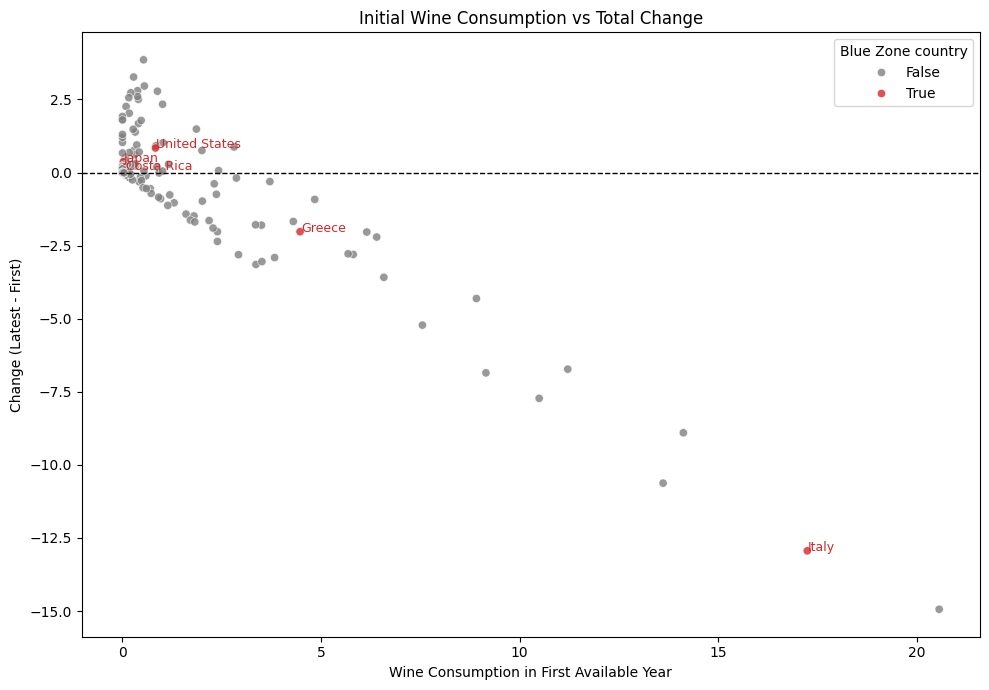

In [71]:
tmp = wine_df.sort_values(["Entity", "Year"]).copy()
change_df = tmp.groupby("Entity").agg(
    start_year=("Year", "first"),
    end_year=("Year", "last"),
    start_value=("Wine Consumption", "first"),
    end_value=("Wine Consumption", "last")
).reset_index()

change_df["total_change"] = change_df["end_value"] - change_df["start_value"]
change_df["is_blue_zone"] = change_df["Entity"].isin(blue_zone_countries)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=change_df,
    x="start_value",
    y="total_change",
    hue="is_blue_zone",
    palette={True: "tab:red", False: "gray"},
    alpha=0.8
)

for _, row in change_df[change_df["is_blue_zone"]].iterrows():
    plt.text(row["start_value"] + 0.02, row["total_change"], row["Entity"], fontsize=9, color="tab:red")

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Initial Wine Consumption vs Total Change")
plt.xlabel("Wine Consumption in First Available Year")
plt.ylabel("Change (Latest - First)")
plt.legend(title="Blue Zone country")
plt.tight_layout()
plt.show()